In [1]:
import os
from pathlib import Path
import numpy as np
import cv2
from matplotlib import pyplot as plt

import insightface
from insightface.app import FaceAnalysis
from insightface.data import get_image as ins_get_image
from insightface.utils import face_align

/home/felipe/miniconda3/envs/proj-rec-facial/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(np.__version__)
print(cv2.__version__)
print(insightface.__version__)

1.23.5
4.8.1
0.7.3


In [3]:
app = FaceAnalysis(providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640,640)) # Valor 0 para GPU
img = ins_get_image('t1')

/home/felipe/miniconda3/envs/proj-rec-facial/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/felipe/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/felipe/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/felipe/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/felipe/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/felipe/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
se

In [4]:
print("Dim:", img.shape)

Dim: (886, 1280, 3)


In [5]:
faces = app.get(img)

/home/felipe/miniconda3/envs/proj-rec-facial/lib/python3.10/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


In [6]:
faces

[{'bbox': array([466.0821 , 268.6164 , 573.58923, 415.5331 ], dtype=float32),
  'kps': array([[491.85046, 321.8314 ],
         [541.85266, 332.11188],
         [507.67114, 366.41312],
         [485.91965, 369.691  ],
         [533.74945, 378.3811 ]], dtype=float32),
  'det_score': 0.9196533,
  'landmark_3d_68': array([[ 4.69443695e+02,  2.96989471e+02,  7.57227936e+01],
         [ 4.68134155e+02,  3.12719116e+02,  7.92197113e+01],
         [ 4.66747955e+02,  3.28960175e+02,  8.15076981e+01],
         [ 4.66053284e+02,  3.45325989e+02,  8.09227753e+01],
         [ 4.66922272e+02,  3.62514740e+02,  7.33340378e+01],
         [ 4.71003143e+02,  3.77187256e+02,  6.58566513e+01],
         [ 4.75966827e+02,  3.90255829e+02,  5.81926956e+01],
         [ 4.82846588e+02,  4.03262604e+02,  4.71076164e+01],
         [ 4.97964294e+02,  4.14659698e+02,  4.25628624e+01],
         [ 5.16660706e+02,  4.12995361e+02,  4.67766647e+01],
         [ 5.30892578e+02,  4.03689392e+02,  5.69011192e+01],
       

In [7]:
rimg = app.draw_on(img, faces)
cv2.imwrite('./t1_output.jpg', rimg)

True

In [8]:
image_path = Path().cwd() / 'examples/Silvio_Santos.jpg'

In [9]:

imagem = cv2.imread(str(image_path))
faces = app.get(imagem)

/home/felipe/miniconda3/envs/proj-rec-facial/lib/python3.10/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


In [10]:
img_with_faces = app.draw_on(imagem, faces)

In [11]:
img_with_faces.shape

(1342, 960, 3)

In [12]:
# output_filename = "face_det_output.jpg"
# cv2.imwrite(output_filename, img_with_faces)

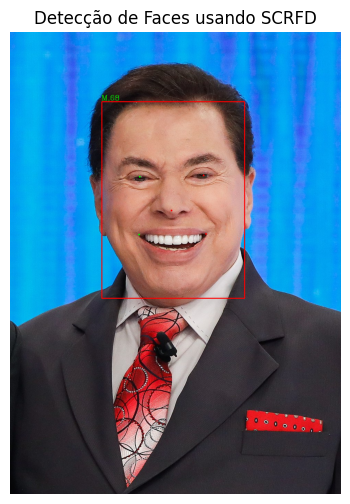

In [13]:
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img_with_faces, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Detecção de Faces usando SCRFD')
plt.show()

In [16]:
for face in faces:
    bbox = face.bbox
    landmark = face.kps
    confidence_det = face.det_score
    normed_emb = face.normed_embedding
    value_l2 = face.embedding_norm
    sex = face.sex
    age = face.age
    print(confidence_det)
    print(sex, age)
    print(value_l2)
    aligned_face = face_align.norm_crop(imagem, landmark=landmark)
    # cv2.imwrite("rosto_alinhado.jpg", aligned_face)

0.9069948
M 68
22.008831


In [17]:
face.keys()

dict_keys(['bbox', 'kps', 'det_score', 'landmark_3d_68', 'pose', 'landmark_2d_106', 'gender', 'age', 'embedding'])